In [4]:
import torch
import torch.nn as nn
import torchvision.models as models

In [5]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

device

'cuda'

# **Implement EfficientNet-B0 model with Transfer Learning**

In [6]:
def tumor_detection_model(num_classes=4, freeze_weights=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    if freeze_weights:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes)
    )

    return model

In [16]:
classes = 4 # Glioma, Meningioma, Pituitary, Normal
model = tumor_detection_model(num_classes=classes, freeze_weights=False)
model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=1280, out_features=4, bias=True)
  )
)


# **Data Loading**

In [2]:
!curl -L -o brain-tumor-mri-dataset-for-model-training.zip https://www.kaggle.com/api/v1/datasets/download/hashirehtisham06/brain-tumor-mri-dataset-for-model-training

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  302M  100  302M    0     0   122M      0  0:00:02  0:00:02 --:--:--  133M


In [ ]:
!unzip /content/brain-tumor-mri-dataset-for-model-training.zip

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [9]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [10]:
train_dataset = datasets.ImageFolder(
    root = '/content/final/final/train',
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root = '/content/final/final/val',
    transform=test_transform
)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training dataset size: {len(train_dataset)}\n"
      f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 9650
Testing dataset size: 1305


# **Training**

In [50]:
import copy

def validate(model, criterion, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return total_loss / len(data_loader), 100 * correct / total

def train(model, criterion, optimizer, train_loader, test_loader, n_epochs, scheduler=None, patience=None):
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    best_test_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(n_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct_train / total_train

        # Test
        epoch_test_loss, epoch_test_acc = validate(model, criterion, test_loader)

        if scheduler:
            # Adjusts learning rate based on loss if ReduceLROnPlateau is used
            scheduler.step(epoch_test_loss)

        # Store history
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)
        train_accuracies.append(epoch_train_acc)
        test_accuracies.append(epoch_test_acc)

        print(f'Epoch {epoch+1}/{n_epochs}: '
              f'Train[Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}%] | '
              f'Test[Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.2f}%]')

        # Save best model
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if patience is not None and epochs_no_improve >= patience:
                print(f'Early stopping! Best Test Loss: {best_test_loss:.4f}')
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("Model restored to best test results.")

    return train_losses, test_losses, train_accuracies, test_accuracies, best_model_state

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

xentropy = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-5, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=7)
model.to(device)

In [51]:
history = train(model, xentropy, optimizer, train_loader, test_loader, n_epochs=5, patience=5)

Epoch 1/5: Train[Loss: 0.4193, Acc: 97.27%] | Test[Loss: 0.4106, Acc: 97.70%]
Epoch 2/5: Train[Loss: 0.4192, Acc: 97.36%] | Test[Loss: 0.4102, Acc: 97.70%]
Epoch 3/5: Train[Loss: 0.4245, Acc: 96.93%] | Test[Loss: 0.4001, Acc: 98.31%]
Epoch 4/5: Train[Loss: 0.4221, Acc: 97.09%] | Test[Loss: 0.4027, Acc: 98.01%]
Epoch 5/5: Train[Loss: 0.4185, Acc: 97.11%] | Test[Loss: 0.4030, Acc: 97.70%]
Model restored to best test results.


In [54]:
t_losses, v_losses, t_accs, v_accs, best_w = history

# **Results & Graph**

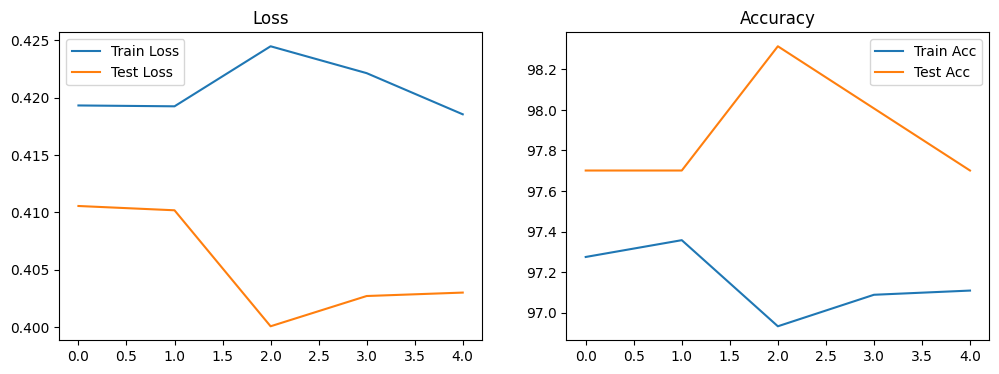

In [55]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t_losses, label='Train Loss'); plt.plot(v_losses, label='Test Loss'); plt.legend(); plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(t_accs, label='Train Acc'); plt.plot(v_accs, label='Test Acc'); plt.legend(); plt.title('Accuracy')
plt.show()

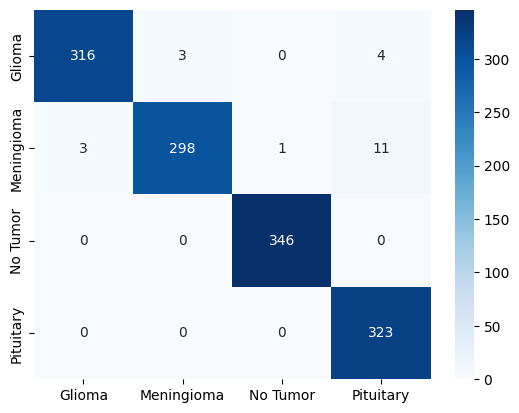

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(model, loader, names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            y_true.extend(lbls.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=names, yticklabels=names, cmap='Blues')
    plt.show()

names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
plot_cm(model, test_loader, names)

In [53]:
final_loss, final_acc = validate(model, xentropy, test_loader)

print(f"Model's Best Test Loss: {final_loss:.4f}")
print(f"Model's Best Test Accuracy: {final_acc:.2f}%")

Model's Best Test Loss: 0.4001
Model's Best Test Accuracy: 98.31%


In [60]:
torch.save(best_w, 'brain_tumor_efficientnet_model.pth')
print("Model successfully saved!")

Model successfully saved!


# **Last Test**

In [59]:
from PIL import Image

# Testing from different datasets images (https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri/data)
def predict_image(image_path, model, transform, class_names):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.nn.functional.softmax(output, dim=1)
        conf, pred = torch.max(prob, 1)

    print(f"Predict: {class_names[pred.item()]} (Confidence: {conf.item()*100:.2f}%)")

class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
predict_image('/content/image(1).jpg', model, test_transform, class_names) # glioma
predict_image('/content/image(1)-2.jpg', model, test_transform, class_names) # meningioma
predict_image('/content/image(1)-3.jpg', model, test_transform, class_names) # no tumor
predict_image('/content/image(1)-4.jpg', model, test_transform, class_names) # pituitary

Predict: glioma (Confidence: 94.57%)
Predict: meningioma (Confidence: 84.66%)
Predict: no_tumor (Confidence: 93.24%)
Predict: pituitary (Confidence: 74.87%)
